In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

read in the data

In [41]:
company_data = pd.read_parquet('./case_study_data/company_data.parquet')
company_data

,entity_urn,updated_at,website,ownership_status,headcount,founding_date,twitter_follower_count,linkedin_follower_count,linkedin_url_harmonic,funding_total,...,emp_delta_12m,adj_emp_delta_12m,investor_1,investor_2,investor_3,Prior VC Backed Founder_count,Deep Technical Background_count,Prior Exit_count,Elite Industry Experience_count,emp_highlight_count
0,urn:harmonic:company:3676293,2025-01-06,"{'domain': 'keye.co', 'is_broken': False, 'url...",PRIVATE,15,2021-01-01,22,3228,https://linkedin.com/company/keye,4.250000,...,9.000000,9.000000,1,0,0,1,0,0,2,15
1,urn:harmonic:company:3823516,2025-01-06,"{'domain': 'stack-ai.com', 'is_broken': False,...",PRIVATE,13,2022-12-01,3905,6775,https://linkedin.com/company/stackai,19.079967,...,9.000000,8.910000,2,0,0,3,3,0,0,20
4,urn:harmonic:company:12475768,2025-01-06,"{'domain': 'extend.app', 'is_broken': False, '...",PRIVATE,10,2023-01-01,<NA>,1121,https://linkedin.com/company/extend-app,0.500000,...,4.000000,4.000000,1,0,0,1,0,0,0,13
5,urn:harmonic:company:49899178,2025-01-06,"{'domain': 'hamming.ai', 'is_broken': False, '...",PRIVATE,12,2024-01-01,<NA>,1140,https://linkedin.com/company/hamming-ai,4.300000,...,5.731260,4.871571,1,0,0,2,1,0,0,10
6,urn:harmonic:company:11125538,2025-01-06,"{'domain': 'vooma.com', 'is_broken': False, 'u...",PRIVATE,15,2023-01-01,<NA>,1345,https://linkedin.com/company/vooma-inc,18.324988,...,7.000000,6.750000,3,1,0,3,2,0,2,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15405,urn:harmonic:company:4418743,2025-01-05,"{'domain': 'theleappartners.com', 'is_broken':...",PRIVATE,21,2004-01-01,<NA>,4400,https://linkedin.com/company/the-leap-partners,0.000000,...,6.000000,6.000000,0,0,0,0,0,0,0,2
15436,urn:harmonic:company:4501758,2025-01-03,"{'domain': 'fullcast.com', 'is_broken': False,...",ACQUIRED_OR_MERGED,4,2018-01-01,<NA>,1208,https://linkedin.com/company/datajoin,3.500000,...,-6.000000,-5.100000,0,0,0,0,0,0,0,0
15438,urn:harmonic:company:651225,2025-01-03,"{'domain': 'topquadrant.com', 'is_broken': Fal...",PRIVATE,36,2001-01-01,1795,1460,https://linkedin.com/company/topquadrant,0.000000,...,4.000000,3.400000,0,0,0,0,0,0,2,15
15439,urn:harmonic:company:52637542,2025-01-06,"{'domain': 'getseam.ai', 'is_broken': False, '...",PRIVATE,11,2023-01-01,<NA>,1073,https://linkedin.com/company/seamai,5.000000,...,4.136969,3.516424,1,0,0,2,0,0,2,20


In [42]:
target_company_data = pd.read_parquet('./case_study_data/target_company_data.parquet')
target_company_data

,entity_urn,updated_at,website,ownership_status,headcount,founding_date,twitter_follower_count,linkedin_follower_count,linkedin_url_harmonic,funding_total,...,emp_delta_12m,adj_emp_delta_12m,investor_1,investor_2,investor_3,Prior VC Backed Founder_count,Deep Technical Background_count,Prior Exit_count,Elite Industry Experience_count,emp_highlight_count
0,urn:harmonic:company:1443095,2024-12-18,"{'domain': 'hebbia.ai', 'is_broken': False, 'u...",PRIVATE,15,2020-08-14,617.0,2076,https://linkedin.com/company/hebbia,31.100000,...,8.0,7.896774,3,0,0,7,3,2,4,80
1,urn:harmonic:company:1990249,2024-12-18,"{'domain': 'axionray.com', 'is_broken': False,...",PRIVATE,18,2021-01-01,NaN,739,https://linkedin.com/company/axion-ray,0.421850,...,8.0,6.800000,1,0,0,0,5,0,9,54
2,urn:harmonic:company:3075425,2024-12-18,"{'domain': 'syrup.tech', 'is_broken': False, '...",PRIVATE,17,2020-07-09,NaN,1590,https://linkedin.com/company/syrup-tech,7.300000,...,9.0,7.633333,1,0,0,1,4,0,2,38
3,urn:harmonic:company:10819970,2024-12-18,"{'domain': 'unstructured.io', 'is_broken': Fal...",PRIVATE,11,2022-01-01,22.0,262,https://linkedin.com/company/unstructuredio,0.421850,...,NaN,NaN,3,0,0,1,5,0,4,63
4,urn:harmonic:company:3928206,2024-12-18,"{'domain': 'smarterdx.com', 'is_broken': False...",PRIVATE,7,2020-01-01,NaN,121,https://linkedin.com/company/smarterdx,5.970000,...,NaN,NaN,3,0,0,2,6,1,5,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,urn:harmonic:company:1842794,2024-12-18,"{'domain': 'siro.ai', 'is_broken': False, 'url...",PRIVATE,6,2020-01-01,NaN,358,https://linkedin.com/company/siro-ai,0.421850,...,-1.0,-1.000000,3,0,0,1,0,0,3,44
57,urn:harmonic:company:48201423,2024-12-16,"{'domain': 'browserbase.com', 'is_broken': Fal...",PRIVATE,19,2024-01-01,3728.0,1412,https://linkedin.com/company/browserbasehq,27.500000,...,NaN,NaN,1,0,0,2,0,0,1,21
58,urn:harmonic:company:773593,2024-12-18,"{'domain': 'pomerium.com', 'is_broken': False,...",PRIVATE,14,2019-01-01,200.0,208,https://linkedin.com/company/pomerium-inc,25.300000,...,2.0,1.893333,4,0,0,1,1,0,1,14
59,urn:harmonic:company:1869576,2024-12-18,"{'domain': 'tavus.io', 'is_broken': False, 'ur...",PRIVATE,13,2020-01-01,NaN,926,https://linkedin.com/company/tavus-io,4.140705,...,5.0,4.647059,8,0,0,2,2,0,2,21


check if the company data overlaps with the target data

In [43]:
target_in_company_data = company_data[company_data['entity_urn'].isin(target_company_data['entity_urn'])] # 58 rows
target_not_in_company_data = target_company_data[~target_company_data['entity_urn'].isin(company_data['entity_urn'])] # 3 rows

separate the target data from the company to do a comparison in their stats

In [44]:
# remove target companies from company_data
company_data = company_data[~company_data['entity_urn'].isin(target_company_data['entity_urn'])] 
company_data # new count = 14835, which is correct because 14893 - 58 = 14835

,entity_urn,updated_at,website,ownership_status,headcount,founding_date,twitter_follower_count,linkedin_follower_count,linkedin_url_harmonic,funding_total,...,emp_delta_12m,adj_emp_delta_12m,investor_1,investor_2,investor_3,Prior VC Backed Founder_count,Deep Technical Background_count,Prior Exit_count,Elite Industry Experience_count,emp_highlight_count
0,urn:harmonic:company:3676293,2025-01-06,"{'domain': 'keye.co', 'is_broken': False, 'url...",PRIVATE,15,2021-01-01,22,3228,https://linkedin.com/company/keye,4.250000,...,9.000000,9.000000,1,0,0,1,0,0,2,15
1,urn:harmonic:company:3823516,2025-01-06,"{'domain': 'stack-ai.com', 'is_broken': False,...",PRIVATE,13,2022-12-01,3905,6775,https://linkedin.com/company/stackai,19.079967,...,9.000000,8.910000,2,0,0,3,3,0,0,20
4,urn:harmonic:company:12475768,2025-01-06,"{'domain': 'extend.app', 'is_broken': False, '...",PRIVATE,10,2023-01-01,<NA>,1121,https://linkedin.com/company/extend-app,0.500000,...,4.000000,4.000000,1,0,0,1,0,0,0,13
5,urn:harmonic:company:49899178,2025-01-06,"{'domain': 'hamming.ai', 'is_broken': False, '...",PRIVATE,12,2024-01-01,<NA>,1140,https://linkedin.com/company/hamming-ai,4.300000,...,5.731260,4.871571,1,0,0,2,1,0,0,10
6,urn:harmonic:company:11125538,2025-01-06,"{'domain': 'vooma.com', 'is_broken': False, 'u...",PRIVATE,15,2023-01-01,<NA>,1345,https://linkedin.com/company/vooma-inc,18.324988,...,7.000000,6.750000,3,1,0,3,2,0,2,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15405,urn:harmonic:company:4418743,2025-01-05,"{'domain': 'theleappartners.com', 'is_broken':...",PRIVATE,21,2004-01-01,<NA>,4400,https://linkedin.com/company/the-leap-partners,0.000000,...,6.000000,6.000000,0,0,0,0,0,0,0,2
15436,urn:harmonic:company:4501758,2025-01-03,"{'domain': 'fullcast.com', 'is_broken': False,...",ACQUIRED_OR_MERGED,4,2018-01-01,<NA>,1208,https://linkedin.com/company/datajoin,3.500000,...,-6.000000,-5.100000,0,0,0,0,0,0,0,0
15438,urn:harmonic:company:651225,2025-01-03,"{'domain': 'topquadrant.com', 'is_broken': Fal...",PRIVATE,36,2001-01-01,1795,1460,https://linkedin.com/company/topquadrant,0.000000,...,4.000000,3.400000,0,0,0,0,0,0,2,15
15439,urn:harmonic:company:52637542,2025-01-06,"{'domain': 'getseam.ai', 'is_broken': False, '...",PRIVATE,11,2023-01-01,<NA>,1073,https://linkedin.com/company/seamai,5.000000,...,4.136969,3.516424,1,0,0,2,0,0,2,20


## Understand growth features

In [45]:
select_features = pd.DataFrame()

In [46]:
target_headcount_features = target_company_data.filter(like='headcount')
target_headcount_features

,headcount,headcount_0m,headcount_1m,headcount_2m,headcount_3m,headcount_4m,headcount_5m,headcount_6m,headcount_7m,headcount_8m,...,headcount_growth_trailing_3m_7m,headcount_growth_trailing_3m_8m,headcount_growth_trailing_3m_9m,headcount_growth_trailing_3m_10m,headcount_growth_trailing_3m_11m,headcount_growth_trailing_3m_12m,headcount_monotonicity,headcount_concavity,max_headcount,adjusted_headcount
0,15,101,15.0,12.0,13.0,10.0,10.0,8.000000,9.0,8.0,...,1.285714,1.142857,1.000000,1.166667,1.166667,1.000000,0.916667,0.636364,31.0,30.6
1,18,215,19.0,21.0,21.0,15.0,15.0,15.000000,15.0,20.0,...,1.153846,1.818182,1.400000,1.625000,1.100000,1.250000,0.833333,0.545455,18.0,0.0
2,17,49,16.0,15.0,15.0,17.0,15.0,15.000000,13.0,12.0,...,1.300000,1.333333,1.375000,1.428571,1.500000,1.333333,0.750000,0.363636,27.0,22.9
3,11,79,11.0,5.0,NaN,NaN,NaN,10.312499,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.750000,0.545455,11.0,0.0
4,7,102,8.0,6.0,6.0,7.0,5.0,3.000000,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.250000,7.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,6,38,7.0,6.0,6.0,7.0,7.0,7.000000,7.0,7.0,...,0.700000,0.777778,1.142857,1.666667,1.500000,1.166667,0.333333,0.636364,16.0,16.0
57,19,19,NaN,NaN,NaN,NaN,NaN,17.812499,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.750000,0.545455,19.0,0.0
58,14,20,13.0,13.0,13.0,13.0,13.0,13.000000,13.0,13.0,...,1.000000,1.000000,1.083333,1.000000,1.083333,1.000000,0.250000,0.818182,15.0,14.2
59,13,31,14.0,12.0,12.0,10.0,10.0,11.000000,12.0,11.0,...,1.333333,1.375000,1.125000,1.125000,1.000000,1.142857,0.750000,0.636364,17.0,15.8


In [47]:
headcount_features = company_data.filter(like='headcount')
headcount_features

,headcount,headcount_0m,headcount_1m,headcount_2m,headcount_3m,headcount_4m,headcount_5m,headcount_6m,headcount_7m,headcount_8m,...,headcount_growth_trailing_3m_7m,headcount_growth_trailing_3m_8m,headcount_growth_trailing_3m_9m,headcount_growth_trailing_3m_10m,headcount_growth_trailing_3m_11m,headcount_growth_trailing_3m_12m,headcount_monotonicity,headcount_concavity,max_headcount,adjusted_headcount
0,15,15,18,17,17,15,10,9.000000,10,11,...,1.000000,1.571429,1.833333,1.666667,1.166667,1.000000,0.666667,0.454545,16.0,16.0
1,13,13,9,9,9,9,8,7.000000,7,8,...,1.750000,2.000000,1.750000,1.000000,1.333333,1.333333,0.666667,0.545455,13.0,9.9
4,10,10,11,11,11,11,12,12.000000,12,11,...,1.333333,1.833333,1.666667,1.500000,1.200000,1.200000,0.583333,0.545455,10.0,10.0
5,12,12,12,10,9,6,7,8.000000,7,6,...,NaN,NaN,NaN,NaN,NaN,NaN,0.833333,0.600000,12.0,0.0
6,15,15,17,14,14,14,12,12.000000,11,11,...,1.100000,1.375000,1.250000,1.250000,1.333333,1.600000,1.000000,0.545455,15.0,13.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15405,21,21,21,21,19,18,17,17.000000,16,16,...,1.066667,1.000000,1.000000,1.000000,1.066667,1.000000,0.750000,0.545455,23.0,23.0
15436,4,4,4,4,4,4,5,5.000000,6,6,...,0.857143,0.857143,0.500000,0.700000,0.538462,0.769231,0.000000,0.727273,4.0,0.0
15438,36,36,37,36,38,38,38,37.000000,38,37,...,1.055556,1.088235,1.125000,1.125000,0.971429,0.914286,0.583333,0.363636,36.0,0.0
15439,11,11,<NA>,<NA>,<NA>,<NA>,<NA>,8.777735,<NA>,<NA>,...,NaN,NaN,NaN,NaN,NaN,NaN,0.750000,0.545455,11.0,0.0


In [72]:
def plot_growth(name, metric, df, num_months=18, growth=False):
    if name != '':
        name = f'{name}_'
    
    month_cols = []
    
    if growth:
        month_cols = [f'{name}{metric}_{m}m' for m in [1, 3, 6, 12]]
        print(month_cols)
    else:
        month_cols = [f'{name}{metric}_{m}m' for m in range(num_months + 1)]

    # Plot setup
    plt.figure(figsize=(8, 4))
    for i, row in df.iterrows():
        y = row[month_cols].apply(lambda x: np.nan if pd.isna(x) else x).values
        if growth:
            plt.plot([1, 3, 6, 12], y, alpha=0.4)
        else:
            plt.plot(range(num_months + 1), y, alpha=0.4)  # label only a few for clarity

    plt.xlabel('Months (0m = reference point)')
    plt.ylabel(f"{metric}")
    plt.title(f'{name} {metric} {num_months} Months Ago (n={len(df)})')
    plt.grid(True)
    plt.tight_layout()

## headcount_[0-18]m

In [73]:
headcount_cols = [f'headcount_{i}m' for i in range(19)]

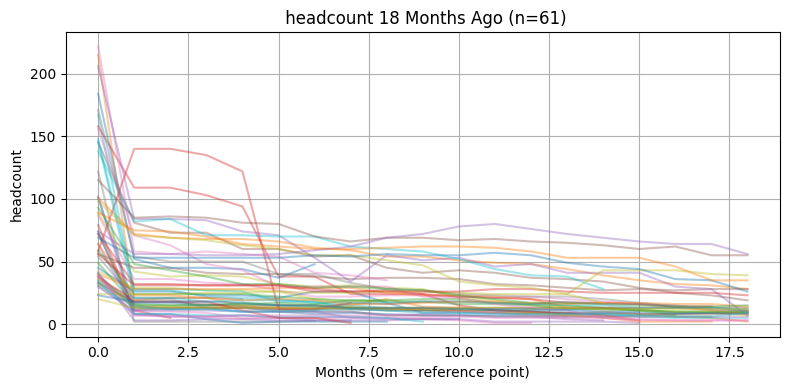

In [74]:
plot_growth('', 'headcount', target_company_data)

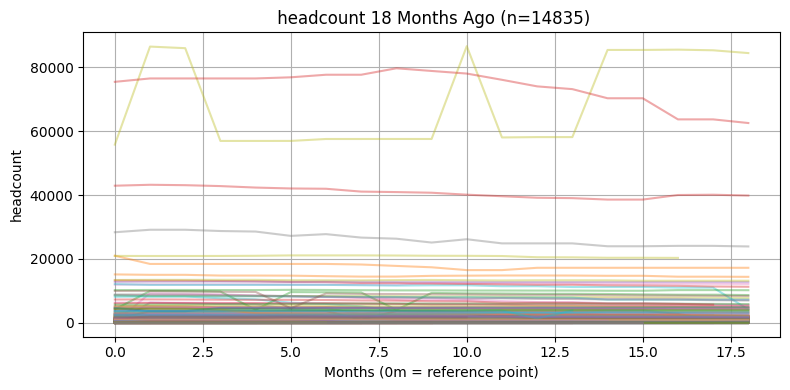

In [63]:
plot_growth('', 'headcount', company_data)

In [52]:
def earliest_valid_month(row):
    for i in range(18, -1, -1):  # Start from oldest (18m) to newest (0m)
        if pd.isna(row[f'headcount_{i}m']):
            continue
        
        if not np.isnan(row[f'headcount_{i}m']):
            return i
    return np.nan  # if no valid headcount at all (very unlikely)


target_headcount_features = target_headcount_features.copy()
target_headcount_features['earliest_valid_month'] = target_headcount_features.apply(earliest_valid_month, axis=1)

headcount_features = headcount_features.copy()
headcount_features['earliest_valid_month'] = headcount_features.apply(earliest_valid_month, axis=1)

I wanted to find the earliest valid month for each company because it would capture how young or recently growing a startup is. If earliest valid month = 0m, it’s very new; if earliest valid month = 15m, it’s more established.

I did notice there was missing data for 1-5 months ago but the earliest valid month being 6, so I also want to add the feature num_valid_months to signal data completeness

In [56]:
target_headcount_features['num_valid_months'] = target_headcount_features[headcount_cols].notna().sum(axis=1)
headcount_features['num_valid_months'] = headcount_features[headcount_cols].notna().sum(axis=1)

### headcount_volatility_score
- calculating the coefficient of variation

- high std dev -> lots of fluctuation in headcount, counts are spread out from mean
- low std dev -> stable headcount, counts are close to mean

- we then need to divide the std dev by the mean in order to compare all company sizes on the same scale and keep the volatility score relative to the company's own size

In [57]:
def calculate_headcount_volatility_score(df):
    # Standard deviation and mean over 0m to 18m
    std_18m = df[headcount_cols].std(axis=1)
    mean_18m = df[headcount_cols].mean(axis=1)

    # Coefficient of Variation
    headcount_volatility_score_18m = std_18m / mean_18m

    return headcount_volatility_score_18m

In [58]:
target_headcount_features['headcount_volatility_score'] = calculate_headcount_volatility_score(target_headcount_features)
headcount_features['headcount_volatility_score'] = calculate_headcount_volatility_score(headcount_features)

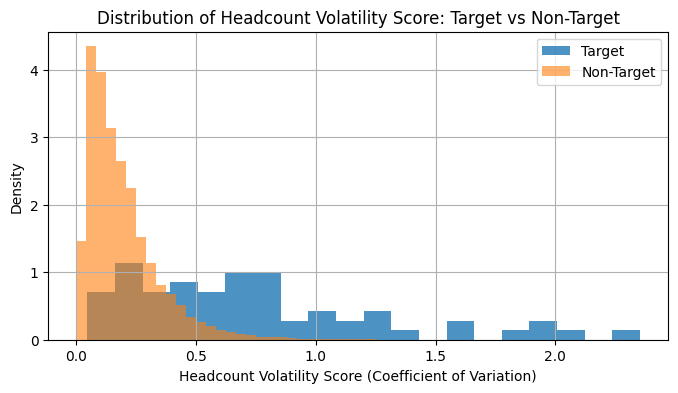

In [59]:
plt.figure(figsize=(8, 4))
plt.hist(target_headcount_features['headcount_volatility_score'].dropna(), bins=20, alpha=0.8, label='Target', density=True)
plt.hist(headcount_features['headcount_volatility_score'], bins=50, alpha=0.6, label='Non-Target', density=True)
plt.xlabel('Headcount Volatility Score (Coefficient of Variation)')
plt.ylabel('Density')
plt.title('Distribution of Headcount Volatility Score: Target vs Non-Target')
plt.legend()
plt.grid(True)
plt.show()

## headcount_growthXm

['headcount_growth_1m', 'headcount_growth_3m', 'headcount_growth_6m', 'headcount_growth_12m']


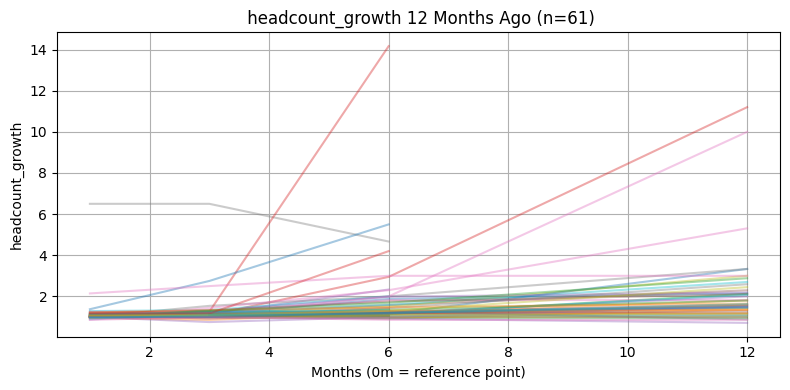

In [75]:
plot_growth('', 'headcount_growth', target_company_data, num_months=12, growth=True)

## Handle missing values
- analyze missing value stats between company data and target company data

Because their is a huge imbalance between the target (positive) group compared to the rest of the data, we have to keep in mind that the missing% is not equivalent between the target group and the rest of the data. However the difference in their missing% can tell us if a feature could be an indicator of a target company. We do have to keep in mind not to blindly use a feature just because its present in the target companies but not in the rest of the data because that can cause overfitting.

In [6]:
unique_dtypes = company_data.dtypes.unique()
unique_dtypes

array([string[python], dtype('<M8[ns]'), dtype('O'), Int64Dtype(),
       dtype('float64'), datetime64[ns, UTC]], dtype=object)

In [7]:
def clean_missing_data(df):
    # print(df.select_dtypes(include=['string']).columns)
    # print(df.select_dtypes(include=['object']).columns)

    for col in df.select_dtypes(include=['string']).columns:
        # replace empty strings with NaN
        df.loc[:, col] = df[col].str.strip()
        df.loc[:, col] = df[col].replace('', np.nan)

    for col in df.select_dtypes(include=['object']).columns:
        df.loc[:, col] = df[col].apply(lambda x: np.nan if isinstance(x, list) and len(x) == 0 else x)

    return df

In [8]:
company_data = clean_missing_data(company_data)
target_company_data = clean_missing_data(target_company_data)

In [9]:
# calculate missing % for each group
missing_target = target_company_data.isna().mean() * 100
missing_rest = company_data.isna().mean() * 100

# combine into one table for comparison
missing_comparison = pd.DataFrame({
    'missing_pct_target': missing_target,
    'missing_pct_rest': missing_rest,
    'missing_pct_diff': (missing_target - missing_rest).abs()
}).sort_values(by='missing_pct_diff', ascending=False)

missing_comparison

,missing_pct_target,missing_pct_rest,missing_pct_diff
owner_id,16.393443,71.304348,54.910905
education,63.934426,13.333333,50.601093
ceo_country,16.393443,62.608696,46.215253
different_ceo_city,14.754098,59.278733,44.524634
ceo_state,22.950820,66.140883,43.190063
...,...,...,...
Africa,0.000000,0.000000,0.000000
Asia,0.000000,0.000000,0.000000
Europe,0.000000,0.000000,0.000000
South America,0.000000,0.000000,0.000000


owner id seems to only have a high missing % in the rest of the data but not in the target data so let's analyze that

In [10]:
unique_owner_ids = company_data['owner_id'].dropna()
unique_target_owner_ids = target_company_data['owner_id'].dropna()

print("Unique owner_ids in company_data:", unique_owner_ids.unique().tolist())
print("\nUnique owner_ids in target_company_data:", unique_target_owner_ids.unique().tolist())

print("\nCompany data with owner_id in target company data:")
print(set(unique_owner_ids.unique().tolist()) & set(unique_target_owner_ids.unique().tolist()))

print("\nCount of owner_id in company_data that are also in target_company_data:", unique_owner_ids.isin(unique_target_owner_ids).value_counts())

Unique owner_ids in company_data: [116340679.0, 140413660.0, 106378724.0, 141907840.0, 149150375.0, 185480585.0, 73154661.0, 26160477.0, 137286187.0, 145257305.0, 157747990.0, 133437152.0]

Unique owner_ids in target_company_data: [149150375.0, 141907840.0, 116340679.0, 140413660.0, 73154661.0, 26160477.0]

Company data with owner_id in target company data:
{141907840.0, 73154661.0, 149150375.0, 116340679.0, 140413660.0, 26160477.0}

Count of owner_id in company_data that are also in target_company_data: owner_id
True     3700
False     557
Name: count, dtype: int64


Although there is a 87% overlap in non-missing data for owner_id between the target group and the rest of the data I don't want the model to overfit based on this features indication also intuitively it does not make sense to know whether a company is doing well based on owner id, so right now it is okay to not use this feature and further engineer it

In [11]:
good_features = missing_comparison[missing_comparison['missing_pct_diff'] < 20].index.tolist()
good_features

['linkedin_follower_count_8m',
 'twitter_follower_count_17m',
 'twitter_follower_count_16m',
 'headcount_growth_trailing_3m_5m',
 'headcount_8m',
 'twitter_follower_count_0m',
 'linkedin_follower_count_5m',
 'linkedin_follower_growth_6m',
 'linkedin_follower_count_6m',
 'linkedin_follower_count_7m',
 'twitter_follower_count_13m',
 'twitter_follower_count_14m',
 'twitter_follower_count_15m',
 'twitter_follower_count_10m',
 'headcount_growth_trailing_3m_3m',
 'headcount_7m',
 'headcount_growth_trailing_3m_4m',
 'twitter_follower_count_9m',
 'twitter_follower_count',
 'linkedin_follower_growth_3m',
 'linkedin_follower_count_3m',
 'headcount_5m',
 'headcount_growth_trailing_3m_2m',
 'linkedin_follower_count_4m',
 'ownership_status',
 'last_funding_total',
 'headcount_3m',
 'headcount_growth_trailing_3m_0m',
 'linkedin_follower_count_1m',
 'linkedin_follower_growth_1m',
 'linkedin_follower_count_2m',
 'headcount_growth_trailing_3m_1m',
 'headcount_4m',
 'headcount_1m',
 'headcount_growth_1m

## Basic filtering
- drop irrelevant features such as identifiers, urls, name

In [12]:
good_features = [col for col in good_features if col not in ['website', 'entity_urn', 'harmonic_url', 'name', 'domain', 'domain_only', 'hostname', 'description', 'linkedin_company', 'linkedin_url_harmonic']]
good_features

['linkedin_follower_count_8m',
 'twitter_follower_count_17m',
 'twitter_follower_count_16m',
 'headcount_growth_trailing_3m_5m',
 'headcount_8m',
 'twitter_follower_count_0m',
 'linkedin_follower_count_5m',
 'linkedin_follower_growth_6m',
 'linkedin_follower_count_6m',
 'linkedin_follower_count_7m',
 'twitter_follower_count_13m',
 'twitter_follower_count_14m',
 'twitter_follower_count_15m',
 'twitter_follower_count_10m',
 'headcount_growth_trailing_3m_3m',
 'headcount_7m',
 'headcount_growth_trailing_3m_4m',
 'twitter_follower_count_9m',
 'twitter_follower_count',
 'linkedin_follower_growth_3m',
 'linkedin_follower_count_3m',
 'headcount_5m',
 'headcount_growth_trailing_3m_2m',
 'linkedin_follower_count_4m',
 'ownership_status',
 'last_funding_total',
 'headcount_3m',
 'headcount_growth_trailing_3m_0m',
 'linkedin_follower_count_1m',
 'linkedin_follower_growth_1m',
 'linkedin_follower_count_2m',
 'headcount_growth_trailing_3m_1m',
 'headcount_4m',
 'headcount_1m',
 'headcount_growth_1m

In [13]:
company_data = company_data[good_features]
target_company_data = target_company_data[good_features]

In [14]:
company_data

,linkedin_follower_count_8m,twitter_follower_count_17m,twitter_follower_count_16m,headcount_growth_trailing_3m_5m,headcount_8m,twitter_follower_count_0m,linkedin_follower_count_5m,linkedin_follower_growth_6m,linkedin_follower_count_6m,linkedin_follower_count_7m,...,United States Engineering,United States Sales,Other,Unknown,Oceania,Africa,Asia,Europe,South America,emp_highlight_count
0,1602,22.0,23.0,0.909091,11,22.0,1667,1.957550,1649,1636,...,0,0,1,8,0,0,0,0,0,15
1,4166,200.0,812.0,1.000000,8,3905.0,6227,1.195729,5666,5192,...,1,0,3,11,0,0,0,0,0,20
4,671,NaN,NaN,1.090909,11,NaN,846,1.594595,703,688,...,2,2,0,10,0,0,0,0,0,13
5,45,NaN,NaN,1.166667,6,NaN,181,8.085107,141,119,...,0,0,1,9,0,0,0,0,0,10
6,495,NaN,NaN,1.090909,11,NaN,603,2.472426,544,528,...,1,0,0,10,0,0,0,0,0,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15405,3775,NaN,NaN,1.062500,16,NaN,3761,1.169902,3761,3766,...,0,0,9,13,0,0,0,0,0,2
15436,1193,NaN,NaN,0.833333,6,NaN,1201,1.011725,1194,1194,...,0,0,5,7,0,0,0,0,0,0
15438,1281,1804.0,1804.0,1.027027,37,1795.0,1399,1.083890,1347,1319,...,0,0,10,25,0,0,0,1,0,15
15439,<NA>,NaN,NaN,NaN,<NA>,NaN,<NA>,NaN,<NA>,<NA>,...,1,0,1,10,0,0,0,0,0,20


## Parse List[Dict] features

In [15]:
def is_list_or_array(series):
    return series.dropna().apply(lambda x: isinstance(x, (list, np.ndarray))).any()

In [16]:
list_dict_cols = [col for col in company_data.columns if is_list_or_array(company_data[col])]
print("Columns with list or array values in company_data:", list_dict_cols)

list_dict_cols_target = [col for col in target_company_data.columns if is_list_or_array(target_company_data[col])]
print("Columns with list or array values in target_company_data:", list_dict_cols_target)

Columns with list or array values in company_data: ['investors', 'employee_highlights', 'highlights']
Columns with list or array values in target_company_data: ['investors', 'employee_highlights', 'highlights']


In [17]:
company_data = company_data.copy()
target_company_data = target_company_data.copy()

### investors

In [18]:
company_data['num_investors'] = company_data['investors'].apply(lambda x: len(x) if is_list_or_array else 0)
target_company_data['num_investors'] = target_company_data['investors'].apply(lambda x: len(x) if is_list_or_array else 0)

In [19]:
company_data[['investor_1', 'investor_2', 'investor_3']].isna().sum()

investor_1    0
investor_2    0
investor_3    0
dtype: int64

In [20]:
num_investor_notequal_investor_1_2_3 = company_data['num_investors'] != company_data[['investor_1', 'investor_2', 'investor_3']].notna().sum(axis=1)
print("Number of rows where num_investors does not match investor_1 + investor_2 + investor_3:", num_investor_notequal_investor_1_2_3.sum())

Number of rows where num_investors does not match investor_1 + investor_2 + investor_3: 13680


Because there is a large number of instances where num_investors does not equal to investor_1 count + investor_2 count + investor_3 count, we can't quite define what investor_1, investor_2, and investor_3 mean just yet. This can however rule out the meaning behind investor_1, investor_2, and investor_3 being tiers. Rather they seem to be rounds and there is the possibility that an investor invested in multiple rounds and new investors were introduced at different rounds. Also the inconsistency could be for messy or partial data capture.

In [21]:
# drop investors column after extracting num_investors
company_data = company_data.drop(columns=['investors'])
target_company_data = target_company_data.drop(columns=['investors'])

### employee_highlights

In [22]:
from collections import Counter

def extract_categories(df, col_name, prefix):
    category_counts = df[col_name].apply(lambda x: dict(Counter(d['category'] for d in x if 'category' in d)))
    category_counts_df = pd.json_normalize(category_counts).fillna(0).astype(int)
    category_counts_df = category_counts_df.add_prefix(prefix)
    return category_counts_df

category_counts_df = extract_categories(company_data, 'employee_highlights', 'employee_highlight_')
company_data = pd.concat([company_data, category_counts_df], axis=1)

target_category_counts_df = extract_categories(target_company_data, 'employee_highlights', 'employee_highlight_')
target_company_data = pd.concat([target_company_data, target_category_counts_df], axis=1)

In [23]:
# drop employee_highlights column after extracting counts of employee highlight categories
company_data = company_data.drop(columns=['employee_highlights'])
target_company_data = target_company_data.drop(columns=['employee_highlights'])

### highlights

In [24]:
company_data['highlights'] = company_data['highlights'].apply(lambda x: x if isinstance(x, np.ndarray) else [])
target_company_data['highlights'] = target_company_data['highlights'].apply(lambda x: x if isinstance(x, np.ndarray) else [])

In [25]:
from cleanco import basename
from urlextract import URLExtract

extractor = URLExtract()

def extract_vc_count(highlights):
    for item in highlights:
        if item.get('category') == 'Venture Backed' and item.get('text') is not None:
            text = item['text']
            # Remove the "Backed By" prefix
            firms = text.replace('Backed By ', '')
            
            urls = extractor.find_urls(text)
            urls = [url.strip(',') for url in urls]

            firms = firms.split(', ')
            firms = [firm for firm in firms if basename(firm).strip() != '' and firm not in urls]

            # Return number of unique firms
            return len(set(firms))
    return 0  # No Venture Backed category found

In [26]:
company_data['num_unique_vc_backers'] = company_data['highlights'].apply(extract_vc_count)
target_company_data['num_unique_vc_backers'] = target_company_data['highlights'].apply(extract_vc_count)

In [28]:
# drop highlights column after extracting number of venture capital firms backing the company
company_data = company_data.drop(columns=['highlights'])
target_company_data = target_company_data.drop(columns=['highlights'])

drop features that are mostly constant (>99% same value across rows)
- no variance → the model (or any analysis) can't learn anything from a feature that’s always the same.
- extra noise → keeping it would just add unnecessary complexity.

In [29]:
def find_constant_columns(df):
    mostly_constant_cols = []

    for col in df.columns:
        if is_list_or_array(df[col]):
            continue
        else:
            if df[col].nunique(dropna=False) <= 2:
                mostly_constant_cols.append(col)

    print(f"Mostly constant columns: {mostly_constant_cols}")

find_constant_columns(company_data)
find_constant_columns(target_company_data)

Mostly constant columns: ['investor_3']
Mostly constant columns: ['ownership_status', 'country', 'investor_3', 'investor_2', 'country_multiplier', 'North America', 'Oceania', 'Africa', 'South America', 'employee_highlight_$15M Club', 'employee_highlight_$45M Club', 'employee_highlight_$25M Club', 'employee_highlight_$35M Club', 'employee_highlight_$30M Club', 'employee_highlight_$20M Club']


In [34]:
company_data['investor_3'].unique()
target_company_data['investor_3'].unique()

company_data = company_data.drop(columns=['investor_3'])
target_company_data = target_company_data.drop(columns=['investor_3'])

Because both datasets have only the unique value (0) for the feature investor3, it will be dropped. As for the others I will keep because its probably due to chance that those features happen to nunique <= 2 in the target dataset. Needs further analysis before dropping

## Impute missing values

In [31]:
from sklearn.impute import SimpleImputer

def impute_missing_values(df):
    # 1. Separate numeric and categorical columns
    num_cols = df.select_dtypes(include=["float64", "int64"]).columns
    cat_cols = df.select_dtypes(include=["object"]).columns

    # 2. Define imputers
    num_imputer = SimpleImputer(strategy="median")
    cat_imputer = SimpleImputer(strategy="most_frequent")

    # 3. Fit and transform
    df[num_cols] = num_imputer.fit_transform(df[num_cols])
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

    # 4. Check if missing values are handled
    print(df.isnull().sum().sort_values(ascending=False))

In [39]:
company_data.dtypes.unique()

array([Int64Dtype(), dtype('float64'), string[python],
       datetime64[ns, UTC], dtype('<M8[ns]'), dtype('int64')],
      dtype=object)

In [52]:
date_cols = company_data.select_dtypes(include=["datetime64[ns, UTC]", "<M8[ns]"]).columns.tolist()
print('date type columns: ', date_cols, 'length: ', len(date_cols))

string_cols = company_data.select_dtypes(include=["string[python]"]).columns.tolist()
print('string type columns: ', string_cols, 'length: ', len(string_cols))

num_cols = company_data.select_dtypes(include=["float64", "int64"]).columns.tolist()
print('numerical type columns: ', num_cols, 'length: ', len(num_cols))

len(company_data.columns) == len(date_cols) + len(string_cols) + len(num_cols)

date type columns:  ['last_funding_date', 'founding_date', 'updated_at'] length:  3
string type columns:  ['ownership_status', 'funding_stage', 'last_funding_type', 'city', 'country'] length:  5
numerical type columns:  ['linkedin_follower_count_8m', 'twitter_follower_count_17m', 'twitter_follower_count_16m', 'headcount_growth_trailing_3m_5m', 'headcount_8m', 'twitter_follower_count_0m', 'linkedin_follower_count_5m', 'linkedin_follower_growth_6m', 'linkedin_follower_count_6m', 'linkedin_follower_count_7m', 'twitter_follower_count_13m', 'twitter_follower_count_14m', 'twitter_follower_count_15m', 'twitter_follower_count_10m', 'headcount_growth_trailing_3m_3m', 'headcount_7m', 'headcount_growth_trailing_3m_4m', 'twitter_follower_count_9m', 'twitter_follower_count', 'linkedin_follower_growth_3m', 'linkedin_follower_count_3m', 'headcount_5m', 'headcount_growth_trailing_3m_2m', 'linkedin_follower_count_4m', 'last_funding_total', 'headcount_3m', 'headcount_growth_trailing_3m_0m', 'linkedin_fo

True

## Compare feature distributions between the two groups:
- p-value ≈ probability that the two groups are NOT different by chance.

- Small p-value (e.g., < 0.05) 
    - → Unlikely that the difference between the two groups happened randomly →
    - → The feature behaves differently between target and non-target →
    - → Useful for the model to tell them apart!

In [32]:
len(company_data.columns.tolist())

143

In [33]:
from scipy.stats import mannwhitneyu, chi2_contingency

def statistical_feature_test(df_target, df_rest, feature, threshold=0.05):
    try:
        # Numerical feature
        target_values = df_target[feature].dropna()
        rest_values = df_rest[feature].dropna()

        if np.issubdtype(target_values.dtype, np.number):
            stat, p_value = mannwhitneyu(target_values, rest_values, alternative='two-sided')
        else:
            # Categorical feature
            contingency_table = pd.crosstab(df_target[feature], df_rest[feature])
            stat, p_value, _, _ = chi2_contingency(contingency_table)
        
        return p_value < threshold
    except Exception as e:
        print(f"Skipping {feature} due to error: {e}")
        return False